# Generating Receptive Fields with Spike-Triggered Averages

In this tutorial we will simulate an AELIF neuron using the following parameters:

In [49]:
E_L      = -60  # mV, Leak potential
V_th     = -50  # mV, Threshold potential
V_reset  = -80  # mV, Reset potential
delta_th =  2   # mV, Threshold slope factor
G_L      =  8   # nS, Leak conductance
C_m      =  100 # pF, Capacitance
a        =  10  # nS, Adaptation recovery
b        =  0.5 # nA, Spike-triggered adaptation increment
tau_SRA  =  50  # ms, Adaptation time constant

Using the following libraries:

In [50]:
import numpy as np
import matplotlib.pyplot as  plt
import modules.STA as sta

## Part A: Time-Varying Stimulus

In part A, we will treat the stimulus as a single input current
that varies over time and assess what temporal variation of the stimulus is
most likely to lead to a spike in the model neuron. To achieve this, we will use
a stimulus that is held constant for *5ms*, then randomly replaced with a new
stimulus.

### 1. The first goal is to **simulate the neuron** and record the spike times.

#### a. Produce a vector of 40,000 values for the applied current, 
with each value chosen randomly from a uniform distribution between –
0.5 nA and +0.5 nA. These values will be used to produce successive
5 ms blocks with the current fixed in each 5 ms block.

In [51]:
seed = 11
rng_0 = np.random.default_rng(seed) # set seed for reproducibility
v = rng_0.uniform(-0.5e-9, 0.5e-9, 40000)

#### b. Create a time vector in steps of *0.02ms* up to a total time of *40,000x5ms*  and an applied current vector of the same size as the time vector. 
The current vector should contain the *40,000* randomly
generated values from [1.a.], with each value repeated for *250*
timesteps, so that the applied current is constant for *5ms* before
changing to a new value.

In [52]:
dt = 0.02e-3 #s
T = 40000*5e-3 #s

In [53]:
time_vector, applied_current_vector = sta.time_and_current_vectors(T, dt, v)
np.savez(f'data/tut_data_3_1_{seed}.npz', t=time_vector, I=applied_current_vector)

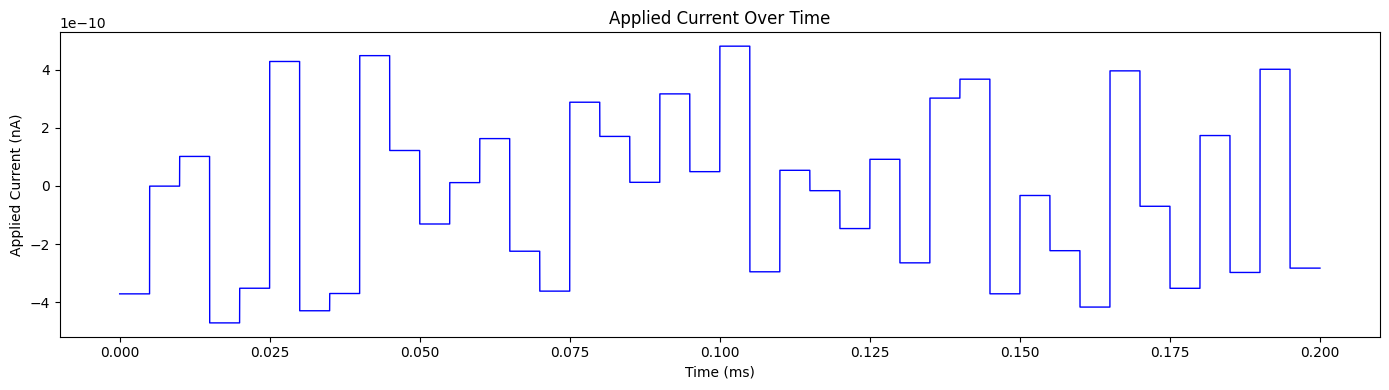

In [54]:
plt.figure(figsize=(14, 4))
plt.plot(time_vector[:10000], applied_current_vector[:10000], marker='', markersize=2.5, linewidth=1, color='blue')
plt.xlabel('Time (ms)')
plt.ylabel('Applied Current (nA)')
plt.title('Applied Current Over Time')
plt.tight_layout()
plt.savefig(f'figs/fig_3_1_{seed}_current.png', dpi=300)
plt.show()

#### c. Simulate the AELIF neuron with the applied current vector from [1.b.] using the preceding parameters. 
Use a simulation timestep, dt=0.02ms. Ensure that all spikes are recorded in a vector of the size of the time vector with a 1 in each time bin that a spike occurs and 0s otherwise.

In [55]:
data = np.load(f'data/aelif_data_3_1_{seed}.npz')
spikes = data['spikes']

### 2. To improve the efficiency of the analysis, we will **downsample** the stimulus and spike vector.

This is best achieved by
writing a function that we will call *expandbin*. The function will take as
inputs an initial vector, an initial bin width, and a final bin width. It will
return an output vector of smaller size than the initial vector, with the
size reduced by a factor equal to the ratio of the bin widths. In particular,
in this tutorial, we are simulating the neuron with a time bin of 0.02 ms
but are only interested in changes on a timescale of 1 ms or more (and
our applied current only changes on a 5 ms timescale). So, we want to
replace our stimulus vector and spike vector with vectors that contain a
value for each 1 ms of time rather than for each 0.02 ms. This requires
downsampling by a factor of 50.

#### a. To achieve the necessary downsampling:

**(i).** Create a function, expandbin, with inputs and outputs as
follows:
function [new_vector] = expandbin(old_vector, old_dt,
new_dt)

**(ii).** Within the function, find the length of old_vector then the scaling
ratio of new_dt divided by old_dt calculated to the nearest
integer.

**(iii).** Calculate the size of new_vector by dividing the size of
old_vector by the scaling ratio. Define new_vector as an array ofzeros of this size.

**(iv).** For successive elements of new_vector calculate the mean
of successive blocks of entries of old_vector. The length of each
block of entries is the scaling factor. In this tutorial, the mean of
a block of 50 of the 0.02 ms time bins in old_vector will be
placed into a 1 ms time bin of new_vector.

In [56]:
def expandbin(old_vector,old_dt,new_dt):
    """
    Downsample a time series by averaging consecutive bins.

    This function groups the input vector into blocks of size
    `new_dt / old_dt` and replaces each block with its average value.

    Parameters
    ----------
    old_vector : array-like
        Original signal or time series sampled with timestep `old_dt`.

    old_dt : float
        Original sampling interval.

    new_dt : float
        Desired sampling interval. Must be an integer multiple
        of `old_dt`.

    Returns
    -------
    numpy.ndarray
        Downsampled vector with timestep `new_dt`, where each
        element is the average of the corresponding block from
        `old_vector`.

    Notes
    -----
    If `r = new_dt / old_dt`, then:
        len(new_vector) = len(old_vector) / r

    The function assumes:
    - `new_dt >= old_dt`
    - `new_dt / old_dt` is an integer
    - `len(old_vector)` is divisible by `r`
    """

    old_l = len(old_vector)

    r = int(new_dt/old_dt)

    new_l = old_l / r

    new_vector = np.zeros(int(new_l))

    for i in range(int(new_l)):

        for j in range(r):

            new_vector[i] += old_vector[i*r+j]/r

    return new_vector

#### b. Send to the function *expandbin* the applied current vector, used to update the membrane potential in the simulations with its timestep of dt,
(note that while your values of
applied current change every 5 ms, the vector used in the
simulations should have a value every dt and the latter is used here),
along with a variable new_dt defined as 1 ms. The function will
return downsampled versions of this vector. Repeat by sending the
simulated vector of spike times to the function, expandbin. Since
spikes are defined as binary, 0 or 1, you should then change all the
reduced spike values in the returned vector back to 1.

In [57]:
new_dt = 1e-3 # s

In [58]:
new_applied_current_vector = expandbin(applied_current_vector, dt, new_dt)

In [59]:
new_spikes = sta.downsample_spikes(spikes, dt, new_dt)

### 3. We will produce and plot the spike-triggered average derived from the two downsampled vectors (the stimulus and the spike times). We will create and use another function, *STA*, to achieve this.

#### a. To create such a function for generating spike-triggered averages:

**(i).** Create the function, STA, with outputs and inputs in the
following format:
function [sta, tcorr] = STA(Iapp, spikes, dt, tminus, …tplus)
where the inputs are respectively: applied current vector; vector
of spike times, with 1 at the time of every spike; the timestep
used in these vectors; the time of the stimulus before a spike to
begin recording; and the time of the stimulus after a spike to
stop recording. Note that the vectors Iapp and spikes must be
the same size.

**(ii).** It is useful in a function to supply default values that are
used if a variable is not passed to it. If only three variables are
passed to the function STA, then the last two will not exist
within the function. In this case, tminus and tplus define the
time window over which the spike-triggered average is
calculated. Within the function, they can be created if they donot already exist using a conditional statement and the in-built
function exist:
if (~exist('tminus’))
Note that the tilde, ~, means “not,” so the line of code following
the conditional is only executed if the variable tminus has not
yet been defined.
Include two such conditional statements to set default values
for tminus and tplus of 75 ms and 25 ms respectively.

**(iii).** Produce integer variables nminus and nplus that
correspond to the number of time bins before and after a spike
over which the stimulus is recorded for averaging.

**(iv).** Define the time window, tcorr, as a vector spanning from
-nminus*dt to nplus*dt in steps of dt. This will provide the x-
coordinates when the spike-triggered average is plotted.

**(v).** Initialize the variable sta to be zero in a vector the same
size as tcorr. This will accumulate values to provide the y-
coordinates when the spike-triggered average is plotted.

**(vi).** Use find to find the time bins that contain spikes.

**(vii).** Loop over all the spike-times found in (vi), for each spike
defining a window that begins a number of bins, nminus, before
the spike and ends a number of bins, nplus, after the spike.
Ensure the window neither begins earlier than the stimulus nor
ends after the stimulus is over (you can ignore the spike in such
cases).

**(viii).** Within the loop, add to the vector sta the values of the
stimulus vector within the window you have just defined for the
spike (as in figure 3.4).

**(ix).** After the loop, to calculate the average stimulus, just
divide sta by the total number of spikes.

In [60]:
def STA(applied_current_vector, spikes, dt, t_minus=75e-3, t_plus=25e-3):
    """
    Compute the spike-triggered average (STA) of an input current signal.

    The STA is obtained by averaging segments of the applied current
    surrounding each spike occurrence. For every spike, a temporal
    window extending `t_minus` before the spike and `t_plus` after
    the spike is extracted and accumulated. The final STA is the mean
    of all valid spike-centered windows.

    Parameters
    ----------
    applied_current_vector : array-like
        Input current time series.

    spikes : array-like
        Binary spike train with the same length as
        `applied_current_vector`. Spike occurrences must be marked
        with value 1.

    dt : float
        Simulation time step.

    t_minus : float, optional
        Time interval before each spike to include in the STA window.
        Default is 75e-3.

    t_plus : float, optional
        Time interval after each spike to include in the STA window.
        Default is 25e-3.

    Returns
    -------
    sta : numpy.ndarray
        Spike-triggered average current waveform.

    time_window : numpy.ndarray
        Time axis corresponding to the STA window, ranging from
        `-t_minus` to `t_plus`.

    Raises
    ------
    ValueError
        If `applied_current_vector` and `spikes` do not have the
        same length.

    Notes
    -----
    Spike windows that would exceed the signal boundaries are ignored.
    """
    
    if len(applied_current_vector) != len(spikes):
        raise ValueError("applied_current_vector and spikes must have the same length.")
    
    n_minus = int(t_minus/dt)
    n_plus = int(t_plus/dt)

    time_window = np.arange(-n_minus*dt, n_plus*dt+dt, dt)

    sta = np.zeros(len(time_window))

    # find time bins where spikes occur:
    spike_bins = np.where(spikes == 1)[0]

    for spike_bin in spike_bins:

        start = spike_bin - n_minus
        end = spike_bin + n_plus

        if start < 0 or end >= len(applied_current_vector):
            continue

        sta += applied_current_vector[start:end+1]

    #print(len(spike_bins))

    sta /= len(spike_bins)

    return sta, time_window

#### b. Now send the downsampled applied current vector and spike train to the function STA, which will return the spike-triggered average and the time window.

In [61]:
spike_triggered_average, time_window = STA(new_applied_current_vector, new_spikes, new_dt)

#### c. Plot the spike-triggered average as a function of the time window around the stimulus.
To adopt conventional coordinates, the x-axis
should be the negative of the time window, so as to represent the
time lag of the spike after the stimulus that produced it. With this
transformation, the STA at positive values of x denotes a causal
relationship.

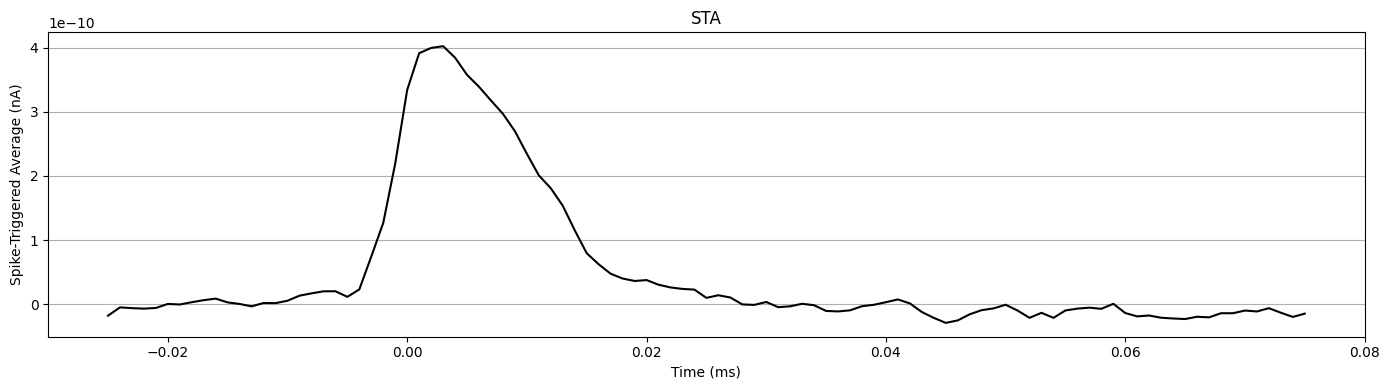

In [62]:
plt.figure(figsize=(14, 4))
plt.plot(-time_window, spike_triggered_average, marker='', markersize=2.5, linewidth=1.5, color='black')
plt.xlabel('Time (ms)')
plt.ylabel('Spike-Triggered Average (nA)')
plt.title('STA')
plt.grid(which='both', axis='y')
plt.tight_layout()
plt.savefig(f'figs/fig_3_1_{seed}_sta.png', dpi=300)
plt.show()

#### d. Comment on how any specific parameters of the AELIF model that we have simulated helped to determine any features of the spike-triggered average in [c.]:

corrigir notação